#  Supervised Learning - Classification

## Agenda
- What is Classification
- Applications of Classification
- Types of Classification
- Binary Classification
  - Logistic Regression
    - Mathematical Concept
    - Example with Breast Cancer Dataset
  - Performance metrics in Classification
    - Confusion Matrix
      - Accuracy
      - Precision
      - Recall
      - F1 Score
      - Specificity
   - Naive Bayes Classifier
     - Mathematical Concept
     - Example with Breast Cancer Dataset
   - K Nearest Neighbors(KNN)
     -  Apply KNN on Breast Cancer Dataset
     -  Hyperparameter Tuning of KNN
   - Decision Tree
     - How Decision Tree Works
     - Metrics for Splitting
     - Pruning
     - Apply DecisionTree on Breast Cancer Data
     - Hyperparameter Tuning Decision Tree
   - Support Vector Machine (SVM)
     - Apply SVM on Breast Cancer Data
     - Hyperparameter Tuning

Major Algorithms for binary classification are:
- Logistic Regression
- Naive Bayes
- K Nearest Neighbors KNN
- Decision Tree
- Support Vector Machine  SVM

# Logistic Regression

In [102]:
import numpy as np

In [103]:
z = -1
sig_z =  1/(1 + np.e**(-z))
print(sig_z)

0.2689414213699951


In [104]:
0.5-0.7310585786300049

-0.2310585786300049

In [105]:
0.5-0.2689414213699951

0.2310585786300049

Apply Logistic Regression on Breast Cancer Dataset

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [107]:
df =  pd.read_csv('breast_cancer_dataset.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [108]:
##drop id and Unnamed: 32


df =  df.drop(columns = ['id', 'Unnamed: 32'])

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [110]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [111]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [112]:
## Target Distribution 
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

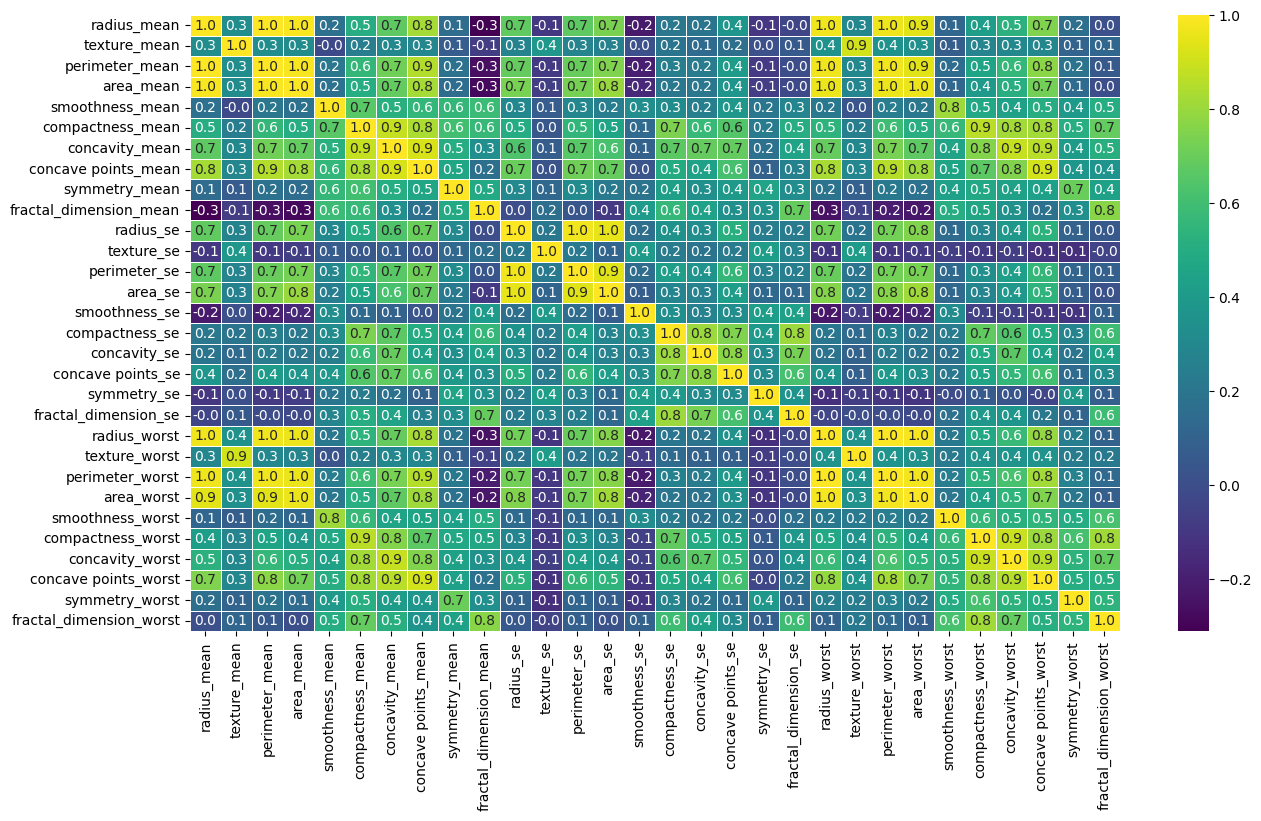

In [113]:
# Check of relationship between input variables

corr_mat =  df.corr(numeric_only = True)
plt.figure(figsize = (15,8))
sns.heatmap(corr_mat, annot = True, fmt = '.1f', linewidths = 0.5, cmap = 'viridis')
plt.show()

In [114]:
# Transform the target variable diagnosis to numerical
from sklearn.preprocessing import LabelEncoder
enc =  LabelEncoder()
df['diagnosis']=  enc.fit_transform(df['diagnosis'])

In [115]:
# Seperate Feature and Target

X = df.drop(columns = ['diagnosis'])
y  = df['diagnosis']

In [116]:
# train test split

X_train, X_test, y_train, y_test =  train_test_split(X,y, test_size = 0.2, random_state = 25)

In [117]:
# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('log_reg', LogisticRegression())
])

# fit the pipeline

pipeline.fit(X_train, y_train)

## predict on train and test data

y_pred_train_log_reg =  pipeline.predict(X_train)
y_pred_test_log_reg =  pipeline.predict(X_test)

## Predict probabilities on test set

y_pred_test_prob_log_reg = pipeline.predict_proba(X_test)[:, 1]

In [118]:
results_df_log_reg =  pd.DataFrame({
    'Actuals': y_test, 
    'Predicted': y_pred_test_log_reg, 
    'Predicted Probability(M)': y_pred_test_prob_log_reg
})

round(results_df_log_reg.head(30), 3)

,Actuals,Predicted,Predicted Probability(M)
522,0,0,0.000
120,0,0,0.000
241,0,0,0.000
362,0,0,0.001
221,0,0,0.013
173,0,0,0.000
525,0,0,0.000
556,0,0,0.000
551,0,0,0.000
454,0,0,0.004


In [119]:
## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_log_reg)
test_acc =  accuracy_score(y_test, y_pred_test_log_reg)

## Print Reports

print('Logistic Regression')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

Logistic Regression
----------------------------------------------------------------------
Training Accuracy : 0.9890
Test Accuracy : 0.9649


In [120]:
## Performance metrics in Classification

## __Date: 29-08-2025__

## Lets Apply All metrics on above model

In [121]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, roc_curve, auc

Logistic Regression
----------------------------------------------------------------------
Training Accuracy : 0.9890
Test Accuracy : 0.9649
Confusion Matrix
[[74  1]
 [ 3 36]]


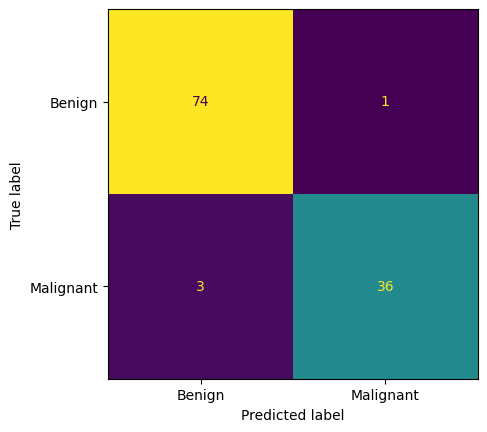

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       0.97      0.92      0.95        39

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



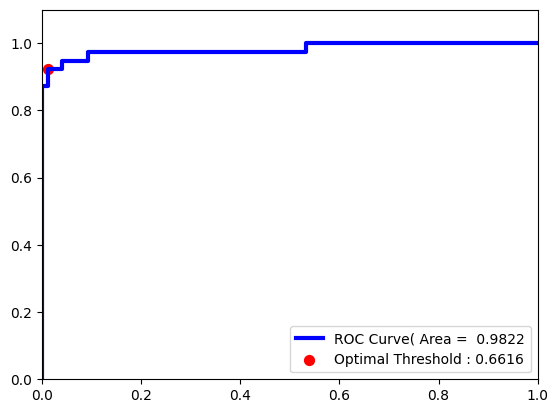

In [122]:
## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_log_reg)
test_acc =  accuracy_score(y_test, y_pred_test_log_reg)

## Print Reports

print('Logistic Regression')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test_log_reg)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ['Benign', 'Malignant'])
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test_log_reg))

## Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob_log_reg)
roc_auc = auc(fpr,tpr)

J = tpr- fpr
optimal_thresh_index = np.argmax(J)
optimal_threshold =  thresholds[optimal_thresh_index]

plt.plot(fpr, tpr, label = f'ROC Curve( Area =  {roc_auc:.4f}', color = 'blue', lw = 3)
plt.scatter(fpr[optimal_thresh_index], tpr[optimal_thresh_index], s =50, color ='red', 
            label = f'Optimal Threshold : {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.legend(loc = 'lower right')
plt.show()

## Naive Bayes Classifier

In [123]:
## Let us implement Naive Bayes. using train test split from previous model

In [124]:
from sklearn.naive_bayes import GaussianNB

In [125]:
# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('gnb', GaussianNB())
])

# fit the pipeline

pipeline.fit(X_train, y_train)

## predict on train and test data

y_pred_train_gnb =  pipeline.predict(X_train)
y_pred_test_gnb =  pipeline.predict(X_test)

## Predict probabilities on test set

y_pred_test_prob_gnb = pipeline.predict_proba(X_test)[:, 1]

Naive Bayes Classifier


----------------------------------------------------------------------
Training Accuracy : 0.9429
Test Accuracy : 0.9035
Confusion Matrix
[[68  7]
 [ 4 35]]


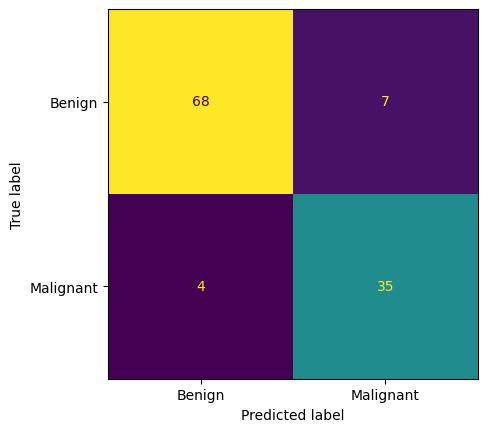

Classification Report
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        75
           1       0.83      0.90      0.86        39

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.89       114
weighted avg       0.91      0.90      0.90       114



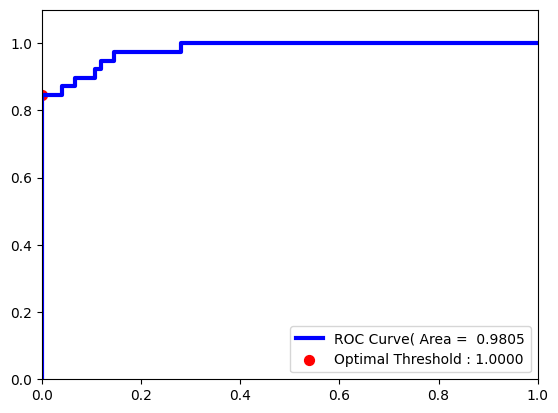

In [126]:
## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_gnb)
test_acc =  accuracy_score(y_test, y_pred_test_gnb)

## Print Reports

print('Naive Bayes Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test_gnb)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ['Benign', 'Malignant'])
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test_gnb))

## Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob_gnb)
roc_auc = auc(fpr,tpr)

J = tpr- fpr
optimal_thresh_index = np.argmax(J)
optimal_threshold =  thresholds[optimal_thresh_index]

plt.plot(fpr, tpr, label = f'ROC Curve( Area =  {roc_auc:.4f}', color = 'blue', lw = 3)
plt.scatter(fpr[optimal_thresh_index], tpr[optimal_thresh_index], s =50, color ='red', 
            label = f'Optimal Threshold : {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.legend(loc = 'lower right')
plt.show()

In [127]:
## K- Nearest Neighbor - used in both Classification and Regression

## Let us implement KNN. using train test split from previous model

K Nearest Neighbors Classifier
----------------------------------------------------------------------
Training Accuracy : 0.9780
Test Accuracy : 0.9561
Confusion Matrix
[[75  0]
 [ 5 34]]


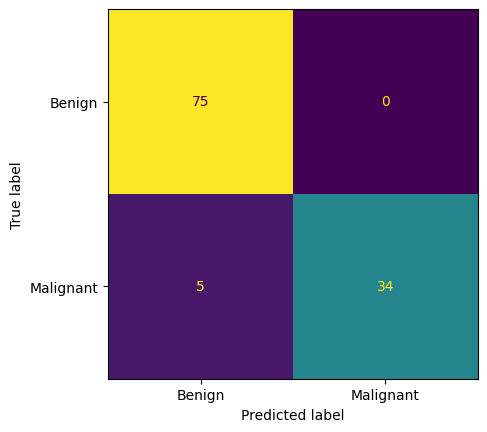

Classification Report
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        75
           1       1.00      0.87      0.93        39

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



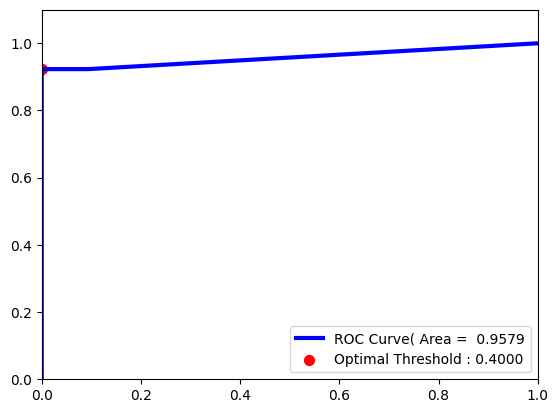

In [128]:
from sklearn.neighbors import KNeighborsClassifier  # for Regression - KNeighborsRegressor


# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('knn', KNeighborsClassifier(n_neighbors =  5))
])

# fit the pipeline

pipeline.fit(X_train, y_train)

## predict on train and test data

y_pred_train_knn =  pipeline.predict(X_train)
y_pred_test_knn =  pipeline.predict(X_test)

## Predict probabilities on test set

y_pred_test_prob_knn = pipeline.predict_proba(X_test)[:, 1]


## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_knn)
test_acc =  accuracy_score(y_test, y_pred_test_knn)

## Print Reports

print('K Nearest Neighbors Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test_knn)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ['Benign', 'Malignant'])
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test_knn))

## Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob_knn)
roc_auc = auc(fpr,tpr)

J = tpr- fpr
optimal_thresh_index = np.argmax(J)
optimal_threshold =  thresholds[optimal_thresh_index]

plt.plot(fpr, tpr, label = f'ROC Curve( Area =  {roc_auc:.4f}', color = 'blue', lw = 3)
plt.scatter(fpr[optimal_thresh_index], tpr[optimal_thresh_index], s =50, color ='red', 
            label = f'Optimal Threshold : {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.legend(loc = 'lower right')
plt.show()

In [129]:
# HyperTune KNN using grid Search

from sklearn.model_selection import GridSearchCV

In [130]:

# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('knn', KNeighborsClassifier())
])

# fit the pipeline using Grid search

param_grid = {'knn__n_neighbors': np.arange(1,21)}

search =  GridSearchCV(pipeline, param_grid, cv = 10, scoring = 'accuracy')

search.fit(X_train, y_train)


print(f'Optimal K : {search.best_params_}')
print(f'Best Score : {search.best_score_}')



Optimal K : {'knn__n_neighbors': 11}
Best Score : 0.9691787439613527


## __Date: 02-09-2025__

## Decision Tree

Decision Tree Classifier
----------------------------------------------------------------------
Training Accuracy : 1.0000
Test Accuracy : 0.9211
Confusion Matrix
[[71  4]
 [ 5 34]]


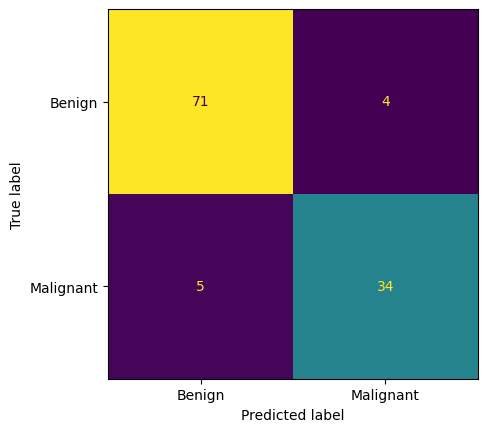

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        75
           1       0.89      0.87      0.88        39

    accuracy                           0.92       114
   macro avg       0.91      0.91      0.91       114
weighted avg       0.92      0.92      0.92       114



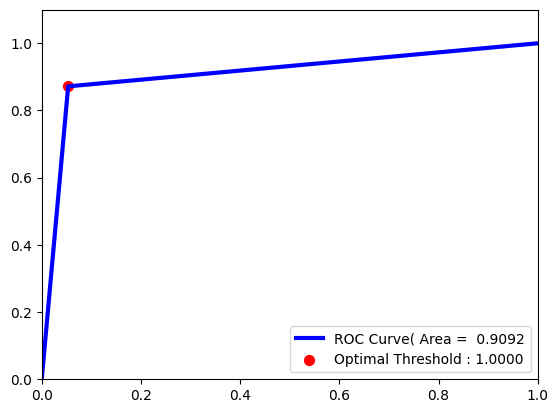

In [131]:
from sklearn.tree import DecisionTreeClassifier  # for Regression - Change Classifier to Regressor


# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('dtc', DecisionTreeClassifier(random_state = 42))
])

# fit the pipeline

pipeline.fit(X_train, y_train)

## predict on train and test data

y_pred_train_dtc =  pipeline.predict(X_train)
y_pred_test_dtc =  pipeline.predict(X_test)

## Predict probabilities on test set

y_pred_test_prob_dtc = pipeline.predict_proba(X_test)[:, 1]


## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_dtc)
test_acc =  accuracy_score(y_test, y_pred_test_dtc)

## Print Reports

print('Decision Tree Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test_dtc)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ['Benign', 'Malignant'])
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test_dtc))

## Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob_dtc)
roc_auc = auc(fpr,tpr)

J = tpr- fpr
optimal_thresh_index = np.argmax(J)
optimal_threshold =  thresholds[optimal_thresh_index]

plt.plot(fpr, tpr, label = f'ROC Curve( Area =  {roc_auc:.4f}', color = 'blue', lw = 3)
plt.scatter(fpr[optimal_thresh_index], tpr[optimal_thresh_index], s =50, color ='red', 
            label = f'Optimal Threshold : {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.legend(loc = 'lower right')
plt.show()

In [132]:
## Tree Pruning

In [133]:
from sklearn.tree import plot_tree

In [134]:
dt =  DecisionTreeClassifier(random_state = 42,max_depth = 3,min_samples_split = 20)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42)

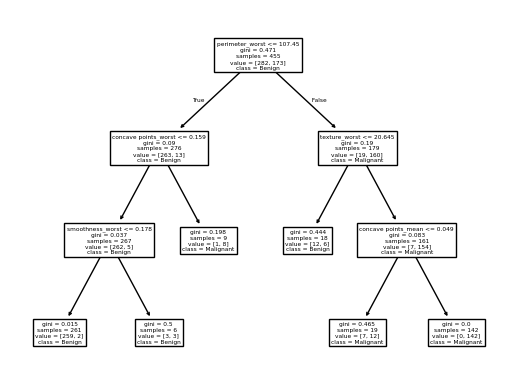

In [135]:
plot_tree(dt, feature_names=X_train.columns, class_names=['Benign', 'Malignant'])
plt.show()

In [136]:
# fit the pipeline

dt.fit(X_train, y_train)

## predict on train and test data

y_pred_train_dt=  dt.predict(X_train)
y_pred_test_dt=  dt.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_dt)
test_acc =  accuracy_score(y_test, y_pred_test_dt)
print(f'Train Acc : {training_acc}')
print(f'Test Acc : {test_acc}')

Train Acc : 0.9582417582417583
Test Acc : 0.9122807017543859


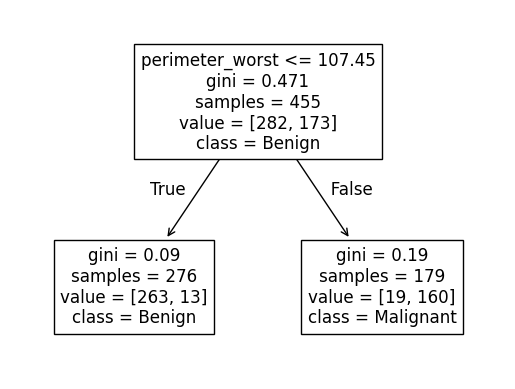

In [137]:
# Post Pruning


dt =  DecisionTreeClassifier(random_state = 42, ccp_alpha = 0.1)
dt.fit(X_train, y_train)

plot_tree(dt, feature_names=X_train.columns, class_names=['Benign', 'Malignant'])
plt.show()

In [138]:
# fit the pipeline

dt.fit(X_train, y_train)

## predict on train and test data

y_pred_train_dt=  dt.predict(X_train)
y_pred_test_dt=  dt.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_dt)
test_acc =  accuracy_score(y_test, y_pred_test_dt)
print(f'Train Acc : {training_acc}')
print(f'Test Acc : {test_acc}')

Train Acc : 0.9296703296703297
Test Acc : 0.868421052631579


In [139]:
dt.get_params()

{'ccp_alpha': 0.1,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [140]:
param_grid = {'ccp_alpha': [0.1, 0.01, 0.001],
 'criterion': ['gini','entropy'],
 'max_depth': [3,4]}

In [141]:
from sklearn.model_selection import GridSearchCV

In [142]:
model = DecisionTreeClassifier()
search = GridSearchCV(model, param_grid, scoring = 'accuracy', cv = 5)
search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'ccp_alpha': [0.1, 0.01, 0.001],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4]},
             scoring='accuracy')

In [143]:
print(search.best_params_)
print(search.best_score_)

{'ccp_alpha': 0.01, 'criterion': 'entropy', 'max_depth': 4}
0.9406593406593406


## Support vector machine

Support Vector Classifier
----------------------------------------------------------------------
Training Accuracy : 0.9890
Test Accuracy : 0.9649
Confusion Matrix
[[74  1]
 [ 3 36]]


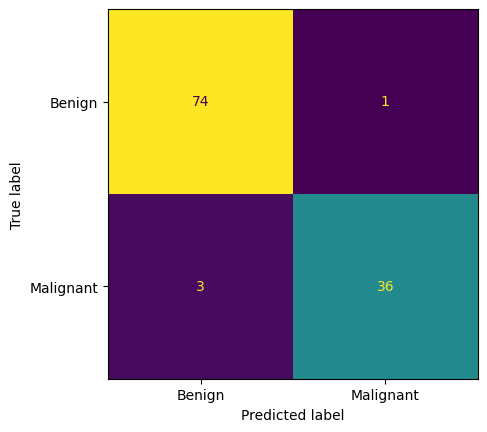

Classification Report
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        75
           1       0.97      0.92      0.95        39

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



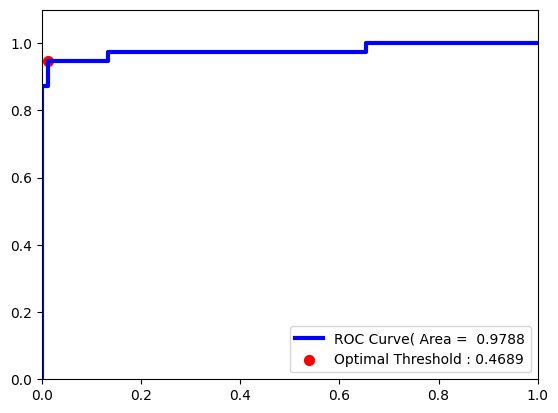

In [144]:
from sklearn.svm import SVC  # for Regression - Change Classifier to Regressor


# Define the Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', SimpleImputer(strategy = 'median')), 
    ('svc', SVC(probability = True))
])

# fit the pipeline

pipeline.fit(X_train, y_train)

## predict on train and test data

y_pred_train_svc =  pipeline.predict(X_train)
y_pred_test_svc =  pipeline.predict(X_test)

## Predict probabilities on test set

y_pred_test_prob_svc = pipeline.predict_proba(X_test)[:, 1]


## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train_svc)
test_acc =  accuracy_score(y_test, y_pred_test_svc)

## Print Reports

print('Support Vector Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test_svc)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat, display_labels = ['Benign', 'Malignant'])
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test_svc))

## Plot ROC Curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_test_prob_svc)
roc_auc = auc(fpr,tpr)

J = tpr- fpr
optimal_thresh_index = np.argmax(J)
optimal_threshold =  thresholds[optimal_thresh_index]

plt.plot(fpr, tpr, label = f'ROC Curve( Area =  {roc_auc:.4f}', color = 'blue', lw = 3)
plt.scatter(fpr[optimal_thresh_index], tpr[optimal_thresh_index], s =50, color ='red', 
            label = f'Optimal Threshold : {optimal_threshold:.4f}')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.1])
plt.legend(loc = 'lower right')
plt.show()

In [145]:
#### implemented bagging

from sklearn.ensemble import BaggingClassifier
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
df = pd.read_csv(url, names = columns)

In [157]:
df.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [162]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [163]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=25)


bagging Model Ensemble Classifier
----------------------------------------------------------------------
Training Accuracy : 0.7638
Test Accuracy : 0.7662
Confusion Matrix
[[87 16]
 [20 31]]


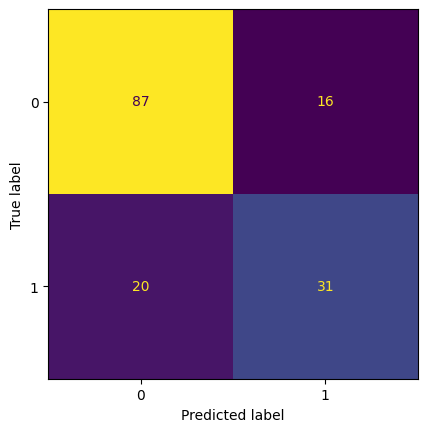

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       103
           1       0.66      0.61      0.63        51

    accuracy                           0.77       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.77      0.76       154



In [170]:
estimators = GaussianNB()
n_estimators = 110000



# create the ensemble model

ensemble_bagging = BaggingClassifier(estimator= estimators, n_estimators= n_estimators, random_state=42, oob_score=True)

ensemble_bagging.fit(X_train, y_train)


## predict on train and test data

y_pred_train =  ensemble_bagging.predict(X_train)
y_pred_test=  ensemble_bagging.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train)
test_acc =  accuracy_score(y_test, y_pred_test)

## Print Reports

print('bagging Model Ensemble Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat)
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test))


bagging Model Ensemble Classifier
----------------------------------------------------------------------
Training Accuracy : 0.8485
Test Accuracy : 0.8052
Confusion Matrix
[[91 12]
 [18 33]]


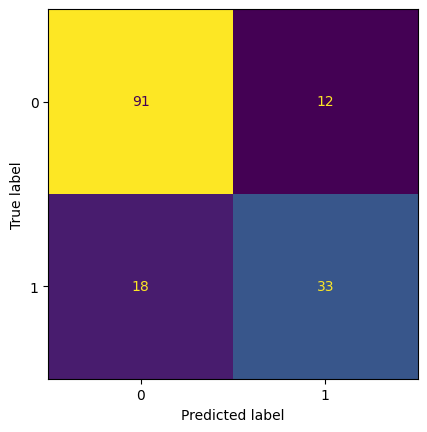

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.88      0.86       103
           1       0.73      0.65      0.69        51

    accuracy                           0.81       154
   macro avg       0.78      0.77      0.77       154
weighted avg       0.80      0.81      0.80       154



In [183]:
from sklearn.ensemble import AdaBoostClassifier

ensemble_adaboost = AdaBoostClassifier(n_estimators=1000, random_state=7)

ensemble_adaboost.fit(X_train, y_train)


## predict on train and test data

y_pred_train =  ensemble_adaboost.predict(X_train)
y_pred_test=  ensemble_adaboost.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train)
test_acc =  accuracy_score(y_test, y_pred_test)

## Print Reports

print('bagging Model Ensemble Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat)
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test))


bagging Model Ensemble Classifier
----------------------------------------------------------------------
Training Accuracy : 0.8013
Test Accuracy : 0.7727
Confusion Matrix
[[94  9]
 [26 25]]


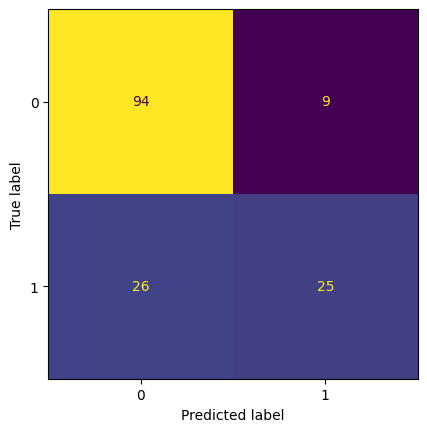

Classification Report
              precision    recall  f1-score   support

           0       0.78      0.91      0.84       103
           1       0.74      0.49      0.59        51

    accuracy                           0.77       154
   macro avg       0.76      0.70      0.72       154
weighted avg       0.77      0.77      0.76       154



In [192]:
from sklearn.ensemble import GradientBoostingClassifier

ensemble_gb = GradientBoostingClassifier(n_estimators=10, random_state=25)

ensemble_gb.fit(X_train, y_train)


## predict on train and test data

y_pred_train =  ensemble_gb.predict(X_train)
y_pred_test=  ensemble_gb.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train)
test_acc =  accuracy_score(y_test, y_pred_test)

## Print Reports

print('bagging Model Ensemble Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat)
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test))


bagging Model Ensemble Classifier
----------------------------------------------------------------------
Training Accuracy : 0.9283
Test Accuracy : 0.7727
Confusion Matrix
[[87 16]
 [19 32]]


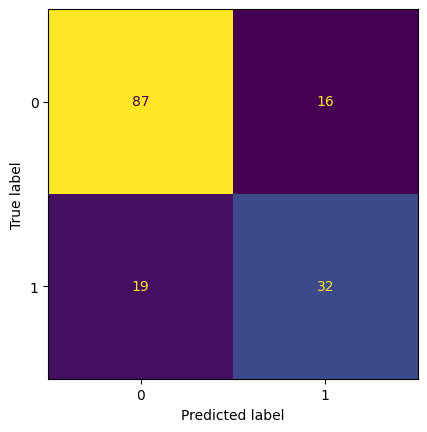

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       103
           1       0.67      0.63      0.65        51

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



In [200]:
from xgboost import XGBClassifier

ensemble_Xgb = XGBClassifier(n_estimators=10, random_state=1, use_label_encoder=False)

ensemble_Xgb.fit(X_train, y_train)


## predict on train and test data

y_pred_train =  ensemble_Xgb.predict(X_train)
y_pred_test=  ensemble_Xgb.predict(X_test)

## Calculate the accuracy for training and testing
training_acc =  accuracy_score(y_train, y_pred_train)
test_acc =  accuracy_score(y_test, y_pred_test)

## Print Reports

print('bagging Model Ensemble Classifier')
print('-' * 70)
print(f'Training Accuracy : {training_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

print('Confusion Matrix')
conf_mat =  confusion_matrix(y_test, y_pred_test)
print(conf_mat)

cm_display  = ConfusionMatrixDisplay(confusion_matrix = conf_mat)
cm_display.plot(colorbar = False)
plt.show()

print('Classification Report')
print(classification_report(y_test, y_pred_test))
